# Zero-DCE++ with SE-Block — v4

## What was wrong in v3 and what changed

**v3 problem:** `L_tv_enh` (weight=500) caused **mode collapse to black images**.
The model found that outputting all-black pixels minimises 4 of 5 losses simultaneously
(`L_tv_enh`, `L_tv_alpha`, `L_spa`, `L_col`), while `L_exp` (weight=10) was too weak
to fight back. Result: PSNR ~8 dB, SSIM ~0.001, completely black output.

| Change | v3 | v4 | Reason |
|---|---|---|---|
| `L_tv_enh` | weight=500 | **REMOVED** | Direct cause of black collapse |
| Exposure loss | global MAE | **per-patch MSE** | Harder to fool, stronger signal |
| Exposure weight | 10 | **20** | Extra protection against collapse |
| Noise fix | `L_tv_enh` | **bilateral filter** at inference only | Correct place for it |
| Aspect-ratio resize | ✅ kept | ✅ kept | Still fixes blocky colour |
| Early stopping | ✅ kept | ✅ kept | Still useful |
| Gradient accumulation | ✅ kept | ✅ kept | Still smooths curve |


### 1. Imports

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import cv2
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Device: cuda
GPU: NVIDIA GeForce RTX 3060


### 2. SE-Block

In [2]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.pool(x).view(b, c)
        w = self.fc(w).view(b, c, 1, 1)
        return x * w

print('SE-Block defined')


SE-Block defined


### 3. DCENet

In [3]:
class DCENet(nn.Module):
    def __init__(self, use_attention=True):
        super().__init__()
        self.use_attention = use_attention
        self.conv1 = nn.Conv2d(3,  32, 3, 1, 1)
        self.conv2 = nn.Conv2d(32, 32, 3, 1, 1)
        self.conv3 = nn.Conv2d(32, 32, 3, 1, 1)
        if use_attention:
            self.se = SEBlock(32, reduction=8)
        self.conv4 = nn.Conv2d(32, 32, 3, 1, 1)
        self.conv5 = nn.Conv2d(64, 32, 3, 1, 1)
        self.conv6 = nn.Conv2d(64, 32, 3, 1, 1)
        self.conv7 = nn.Conv2d(64, 24, 3, 1, 1)
        self.relu  = nn.ReLU(inplace=True)
        nn.init.normal_(self.conv7.weight, mean=0, std=0.01)
        nn.init.constant_(self.conv7.bias, 0)

    def forward(self, x):
        x1 = self.relu(self.conv1(x))
        x2 = self.relu(self.conv2(x1))
        x3 = self.relu(self.conv3(x2))
        if self.use_attention:
            x3 = self.se(x3)
        x4 = self.relu(self.conv4(x3))
        x5 = self.relu(self.conv5(torch.cat([x4, x3], 1)))
        x6 = self.relu(self.conv6(torch.cat([x5, x2], 1)))
        return torch.tanh(self.conv7(torch.cat([x6, x1], 1)))

def enhance_image_with_curves(x, alpha):
    enhanced = x.clone()
    for i in range(8):
        a_i = alpha[:, i*3:(i+1)*3, :, :]
        enhanced = enhanced + a_i * enhanced * (1 - enhanced)
    return torch.clamp(enhanced, 0, 1)

model = DCENet(use_attention=True).to(device)
print(f'Model: {sum(p.numel() for p in model.parameters()):,} parameters')


Model: 79,672 parameters


### 4. Loss Function — v4 (L_tv_enh removed, exposure upgraded)

**Why `L_tv_enh` was removed:**  
A smoothness penalty on the enhanced image has the same minimum as a black image —
zero gradients everywhere. Combined with L_spa and L_col also preferring flat output,
the model collapses. Noise is handled by bilateral filter at inference instead.

**Why exposure loss is upgraded to per-patch MSE:**  
The old `torch.abs(mean - 0.6)` computed ONE number for the whole image.
The model could satisfy it with a bimodal image (some very bright + some very dark patches
averaging to 0.6). Per-patch MSE forces **every 16×16 patch** to be near 0.6 independently.

```
L_total = L_spa + 20·L_exp + 5·L_col + 1600·L_tv_alpha
```


In [4]:
class ZeroDCELoss(nn.Module):
    """
    v4 loss — back to 4 terms, exposure upgraded.

    L_total = L_spa + 20*L_exp + 5*L_col + 1600*L_tv_alpha

    Changes vs v3:
      - L_tv_enh REMOVED (was causing mode collapse to black)
      - L_exp: global MAE -> per-patch MSE (stronger, harder to fool)
      - L_exp weight: 10 -> 20 (extra protection against collapse)
    """
    def __init__(self, E=0.6, patch_size=16):
        super().__init__()
        self.E          = E
        self.patch_size = patch_size

    def forward(self, enhanced, low, alpha):
        enh_g = 0.299*enhanced[:,0:1] + 0.587*enhanced[:,1:2] + 0.114*enhanced[:,2:3]
        low_g = 0.299*low[:,0:1]      + 0.587*low[:,1:2]      + 0.114*low[:,2:3]

        L_spa      = self._spatial_loss(enh_g, low_g)
        L_exp      = self._exposure_loss(enh_g)       # per-patch MSE
        L_col      = self._color_loss(enhanced)
        L_tv_alpha = self._tv_loss(alpha)

        total = L_spa + 20*L_exp + 5*L_col + 1600*L_tv_alpha
        return total, L_spa, L_exp, L_col, L_tv_alpha

    def _spatial_loss(self, enh, low):
        enh_d = F.avg_pool2d(enh, 4)
        low_d = F.avg_pool2d(low, 4)
        d_el = enh_d[:,:,:,1:] - enh_d[:,:,:,:-1];  d_ll = low_d[:,:,:,1:] - low_d[:,:,:,:-1]
        d_er = enh_d[:,:,:,:-1]- enh_d[:,:,:,1:];   d_lr = low_d[:,:,:,:-1]- low_d[:,:,:,1:]
        d_eu = enh_d[:,:,1:,:] - enh_d[:,:,:-1,:];  d_lu = low_d[:,:,1:,:] - low_d[:,:,:-1,:]
        d_ed = enh_d[:,:,:-1,:]- enh_d[:,:,1:,:];   d_ld = low_d[:,:,:-1,:]- low_d[:,:,1:,:]
        return (torch.mean((d_el-d_ll)**2) + torch.mean((d_er-d_lr)**2) +
                torch.mean((d_eu-d_lu)**2) + torch.mean((d_ed-d_ld)**2))

    def _exposure_loss(self, img):
        """
        Per-patch MSE exposure loss.
        Forces EVERY 16x16 patch (not just the global mean) to be near E=0.6.
        Much harder for the model to fool than a single global mean.
        """
        patches = F.avg_pool2d(img, self.patch_size)
        return torch.mean((patches - self.E) ** 2)

    def _color_loss(self, img):
        mr = torch.mean(img[:,0])
        mg = torch.mean(img[:,1])
        mb = torch.mean(img[:,2])
        return torch.abs(mr-mg) + torch.abs(mg-mb) + torch.abs(mb-mr)

    def _tv_loss(self, alpha):
        return (torch.mean(torch.abs(alpha[:,:,:,:-1] - alpha[:,:,:,1:])) +
                torch.mean(torch.abs(alpha[:,:,:-1,:] - alpha[:,:,1:,:])))

loss_fn = ZeroDCELoss(E=0.6, patch_size=16).to(device)
print('Loss function defined')
print('  L_total = L_spa + 20*L_exp(per-patch MSE) + 5*L_col + 1600*L_tv_alpha')


Loss function defined
  L_total = L_spa + 20*L_exp(per-patch MSE) + 5*L_col + 1600*L_tv_alpha


### 5. Dataset — aspect-ratio-preserving resize (from v3, kept)

Short side scaled to `resize_size`, then random crop. Prevents the 400×600→614×614 squash that caused blocky colour.


In [5]:
class LOLDataset(Dataset):
    def __init__(self, image_pairs, img_size=512, augment=False):
        self.image_pairs = image_pairs
        self.img_size    = img_size
        self.augment     = augment
        self.resize_size = int(img_size * 1.15)

    def __len__(self):
        return len(self.image_pairs)

    def __getitem__(self, idx):
        pair = self.image_pairs[idx]
        low_img    = Image.open(pair['low']).convert('RGB')
        normal_img = Image.open(pair['normal']).convert('RGB')

        # Resize by SHORT SIDE — preserves aspect ratio
        low_img    = TF.resize(low_img,    self.resize_size, interpolation=Image.BILINEAR)
        normal_img = TF.resize(normal_img, self.resize_size, interpolation=Image.BILINEAR)

        if self.augment:
            i, j, h, w = transforms.RandomCrop.get_params(
                low_img, (self.img_size, self.img_size))
            low_img    = TF.crop(low_img,    i, j, h, w)
            normal_img = TF.crop(normal_img, i, j, h, w)
            if torch.rand(1) > 0.5:
                low_img    = TF.hflip(low_img)
                normal_img = TF.hflip(normal_img)
        else:
            low_img    = TF.center_crop(low_img,    self.img_size)
            normal_img = TF.center_crop(normal_img, self.img_size)

        return {
            'low':      TF.to_tensor(low_img),
            'normal':   TF.to_tensor(normal_img),
            'filename': pair['filename']
        }

def load_image_pairs(data_path):
    low_p  = data_path / 'Low'
    norm_p = data_path / 'Normal'
    lows   = sorted([f for f in os.listdir(low_p)  if f.endswith(('.jpg','.png'))])
    norms  = sorted([f for f in os.listdir(norm_p) if f.endswith(('.jpg','.png'))])
    assert len(lows)==len(norms), f'Pair mismatch: {len(lows)} vs {len(norms)}'
    return [{'low':str(low_p/l),'normal':str(norm_p/n),'filename':l}
            for l,n in zip(lows,norms)]

BASE_PATH    = Path('LOL-v2')
train_pairs  = load_image_pairs(BASE_PATH / 'Real_captured' / 'Train')
test_pairs   = load_image_pairs(BASE_PATH / 'Real_captured' / 'Test')
print(f'LOL-v2: {len(train_pairs)} train, {len(test_pairs)} test')

BATCH_SIZE  = 8
IMG_SIZE    = 512
train_loader = DataLoader(LOLDataset(train_pairs, IMG_SIZE, augment=True),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(LOLDataset(test_pairs,  IMG_SIZE, augment=False),
                          batch_size=1,          shuffle=False, num_workers=0)
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')


LOL-v2: 689 train, 100 test
Train batches: 87 | Test batches: 100


### 6. Training — Early stopping + gradient accumulation (from v3, kept)

**Collapse guard:** Every 10 epochs, the mean brightness of one batch is checked.
If it drops below 0.1 (near-black), training stops immediately with a warning
rather than wasting time on a collapsed run.


In [6]:
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4
NUM_EPOCHS    = 200
PATIENCE      = 25
ACCUM_STEPS   = 4
CHECKPOINT    = 'best_zerodce_seblock_v4.pth'

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)

history = {'loss':[],'spa':[],'exp':[],'col':[],'tv_a':[],'lr':[]}
best_loss    = float('inf')
no_improve   = 0
stopped_epoch = NUM_EPOCHS

print(f"{'='*60}")
print(f'TRAINING v4 — max {NUM_EPOCHS} epochs, patience={PATIENCE}')
print(f'Effective batch: {BATCH_SIZE}×{ACCUM_STEPS} = {BATCH_SIZE*ACCUM_STEPS}')
print(f"{'='*60}")

for epoch in range(NUM_EPOCHS):
    model.train()
    totals = dict(loss=0, spa=0, exp=0, col=0, tv_a=0)

    optimizer.zero_grad()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f'[{epoch+1}/{NUM_EPOCHS}]')

    for step, batch in pbar:
        low_imgs = batch['low'].to(device)

        alpha    = model(low_imgs)
        enhanced = enhance_image_with_curves(low_imgs, alpha)
        loss, L_spa, L_exp, L_col, L_tv_a = loss_fn(enhanced, low_imgs, alpha)

        (loss / ACCUM_STEPS).backward()

        if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
            optimizer.step()
            optimizer.zero_grad()

        totals['loss'] += loss.item()
        totals['spa']  += L_spa.item()
        totals['exp']  += L_exp.item()
        totals['col']  += L_col.item()
        totals['tv_a'] += L_tv_a.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}',
                          'exp':  f'{L_exp.item():.4f}'})

    n = len(train_loader)
    avg_loss = totals['loss'] / n
    for k in ['loss','spa','exp','col','tv_a']:
        history[k].append(totals[k] / n)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # ── Collapse guard: check mean brightness every 10 epochs ─────
    if (epoch + 1) % 10 == 0:
        model.eval()
        with torch.no_grad():
            sample = next(iter(train_loader))['low'].to(device)
            a_s    = model(sample)
            e_s    = enhance_image_with_curves(sample, a_s)
            mean_brightness = e_s.mean().item()
        model.train()
        print(f'  [Epoch {epoch+1}] mean_brightness={mean_brightness:.4f}', end='')
        if mean_brightness < 0.1:
            print(' — COLLAPSE DETECTED, stopping!')
            stopped_epoch = epoch + 1
            break
        else:
            print(f' | no_improve={no_improve}/{PATIENCE}')

    # ── Early stopping ─────────────────────────────────────────────
    if avg_loss < best_loss:
        best_loss  = avg_loss
        no_improve = 0
        torch.save(model.state_dict(), CHECKPOINT)
        print(f'  Epoch {epoch+1}: loss={avg_loss:.6f}  [BEST saved]')
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            stopped_epoch = epoch + 1
            print(f'  Early stopping at epoch {stopped_epoch}')
            break

    scheduler.step()

print(f"\n{'='*60}")
print(f'DONE — best loss: {best_loss:.6f} | stopped at epoch: {stopped_epoch}')
print(f"{'='*60}")


TRAINING v4 — max 200 epochs, patience=25
Effective batch: 8×4 = 32


[1/200]: 100%|██████████| 87/87 [01:25<00:00,  1.01it/s, loss=9.7802, exp=0.2304]


  Epoch 1: loss=7.888111  [BEST saved]


[2/200]: 100%|██████████| 87/87 [00:42<00:00,  2.03it/s, loss=7.4839, exp=0.3448]


  Epoch 2: loss=7.035967  [BEST saved]


...

  [Epoch 90] mean_brightness=0.3808 | no_improve=4/25


[100/200]: 100%|██████████| 87/87 [00:41<00:00,  2.09it/s, loss=6.3741, exp=0.1186]


  [Epoch 100] mean_brightness=0.6947 | no_improve=14/25


[110/200]: 100%|██████████| 87/87 [00:41<00:00,  2.10it/s, loss=2.1220, exp=0.0840]


  [Epoch 110] mean_brightness=0.5631 | no_improve=24/25
  Early stopping at epoch 110

DONE — best loss: 1.720281 | stopped at epoch: 110


### 7. Training Curves

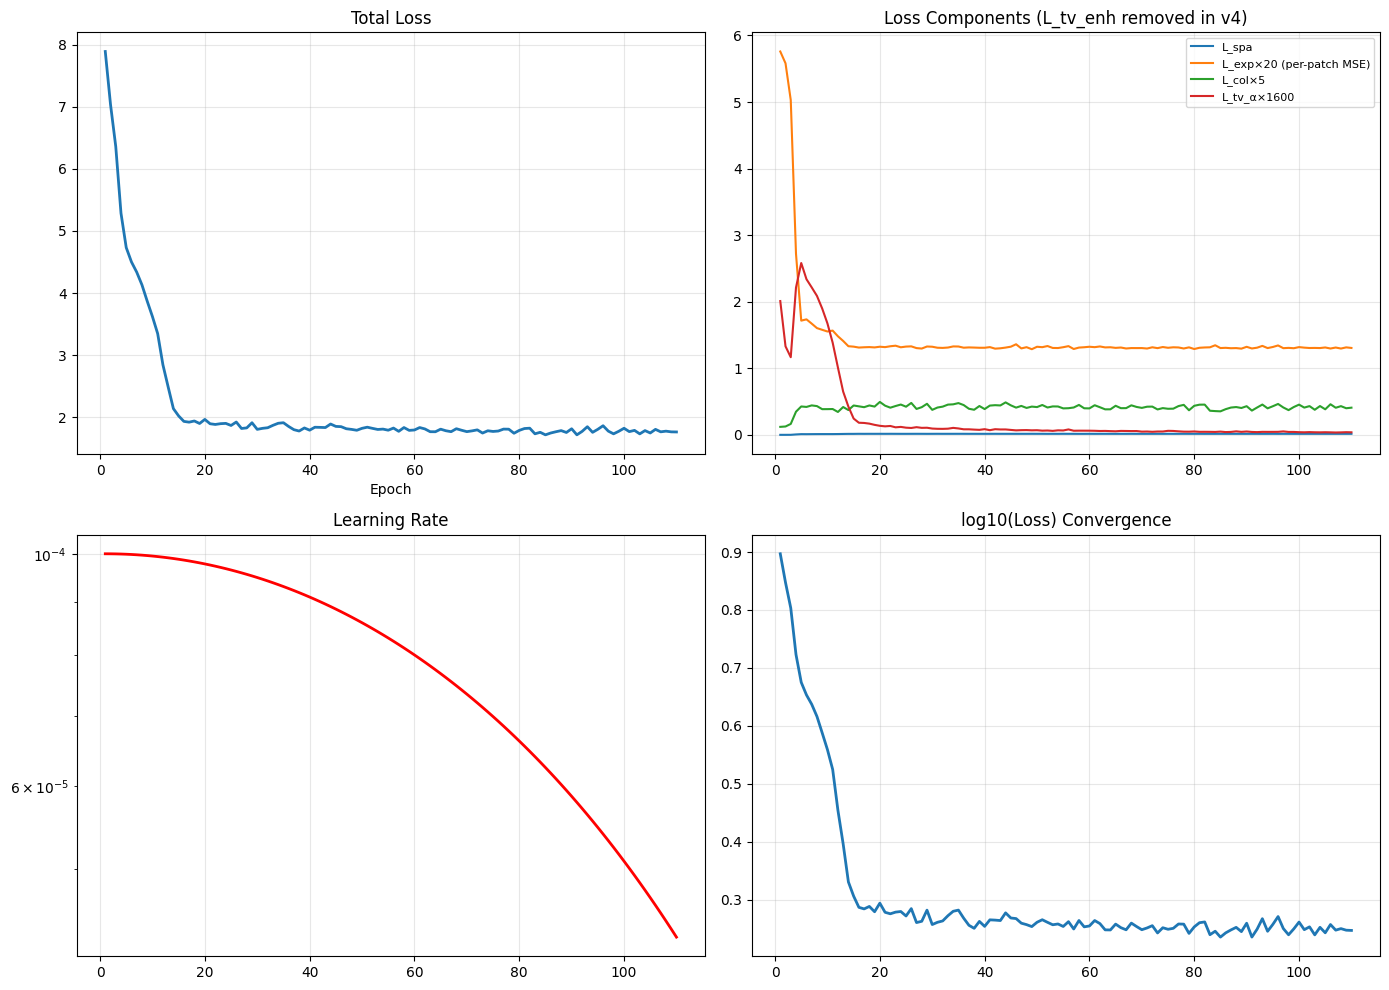

Saved: training_history_v4.png


In [7]:
ep = range(1, len(history['loss'])+1)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(ep, history['loss'], linewidth=2)
axes[0,0].set_title('Total Loss'); axes[0,0].set_xlabel('Epoch')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(ep, history['spa'],                     label='L_spa')
axes[0,1].plot(ep, np.array(history['exp'])*20,        label='L_exp×20 (per-patch MSE)')
axes[0,1].plot(ep, np.array(history['col'])*5,         label='L_col×5')
axes[0,1].plot(ep, np.array(history['tv_a'])*1600,     label='L_tv_α×1600')
axes[0,1].set_title('Loss Components (L_tv_enh removed in v4)')
axes[0,1].legend(fontsize=8); axes[0,1].grid(True, alpha=0.3)

axes[1,0].semilogy(ep, history['lr'], color='red', linewidth=2)
axes[1,0].set_title('Learning Rate'); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(ep, np.log10(np.array(history['loss'])+1e-8), linewidth=2)
axes[1,1].set_title('log10(Loss) Convergence'); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_v4.png', dpi=150)
plt.show()
print('Saved: training_history_v4.png')


### 8. Inference — bilateral filter for real-world photos

Noise is handled HERE (at inference), not during training.
Use `denoise=True` for your own real-world photos, `denoise=False` for metric evaluation.


In [8]:
def enhance_single_image(image_path, checkpoint=CHECKPOINT,
                          denoise=True, d=9, sigma_color=75, sigma_space=75):
    m = DCENet(use_attention=True).to(device)
    m.load_state_dict(torch.load(checkpoint, map_location=device))
    m.eval()

    img = Image.open(image_path).convert('RGB')
    inp = TF.to_tensor(img).unsqueeze(0).to(device)

    with torch.no_grad():
        enh = enhance_image_with_curves(inp, m(inp))

    enh_np = (enh.squeeze(0).cpu().permute(1,2,0).numpy()*255).astype(np.uint8)

    if denoise:
        bgr    = cv2.cvtColor(enh_np, cv2.COLOR_RGB2BGR)
        bgr    = cv2.bilateralFilter(bgr, d=d, sigmaColor=sigma_color, sigmaSpace=sigma_space)
        enh_np = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(np.array(img)); axes[0].set_title('Input (low-light)');  axes[0].axis('off')
    axes[1].imshow(enh_np);        axes[1].set_title('Enhanced v4' + (' + Bilateral' if denoise else ''))
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig('inference_v4.png', dpi=150)
    plt.show()
    return enh_np

print('Usage:')
print('  enhance_single_image("your_photo.jpg", denoise=True)   # real-world photos')
print('  enhance_single_image("lolv2_test.jpg", denoise=False)  # metric evaluation')


Usage:
  enhance_single_image("your_photo.jpg", denoise=True)   # real-world photos
  enhance_single_image("lolv2_test.jpg", denoise=False)  # metric evaluation


---
### Version History

| Version | Key issue | Status |
|---|---|---|
| v1 (original) | `tanh*0.15`, wrong loss weights, broken pairing | Fixed in v2 |
| v2 | Working baseline | Good |
| v3 | `L_tv_enh` weight=500 → mode collapse to black | **Broken** |
| **v4** | `L_tv_enh` removed, exposure upgraded to per-patch MSE, collapse guard added | **Current** |
